In [11]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             roc_curve, auc)
import time

In [4]:
#Load the dataset 
df = pd.read_csv('heart.csv')

#  Display the first 5 rows 
print("--- First 5 Rows of the Dataset ---")
display(df.head())

# Check the shape of the dataset
print(f"\n--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

#  Check for missing values and data types
print("\n--- Dataset Information ---")
df.info()

# Check the distribution of the target variable (0 = No Disease, 1 = Disease)
print("\n--- Target Variable Distribution ---")
print(df['target'].value_counts())

--- First 5 Rows of the Dataset ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0



--- Dataset Shape ---
Rows: 303, Columns: 14

--- Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    str    
 13  target    303 non-null    int64  
dtypes: float64(1), int64(12), str(1)
memory usage: 35.5 KB

--- Target Variable Distribution ---
target
0    220
1     83
Name: count, dtype: int64


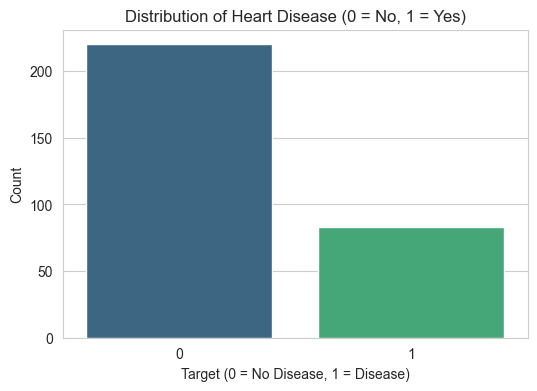

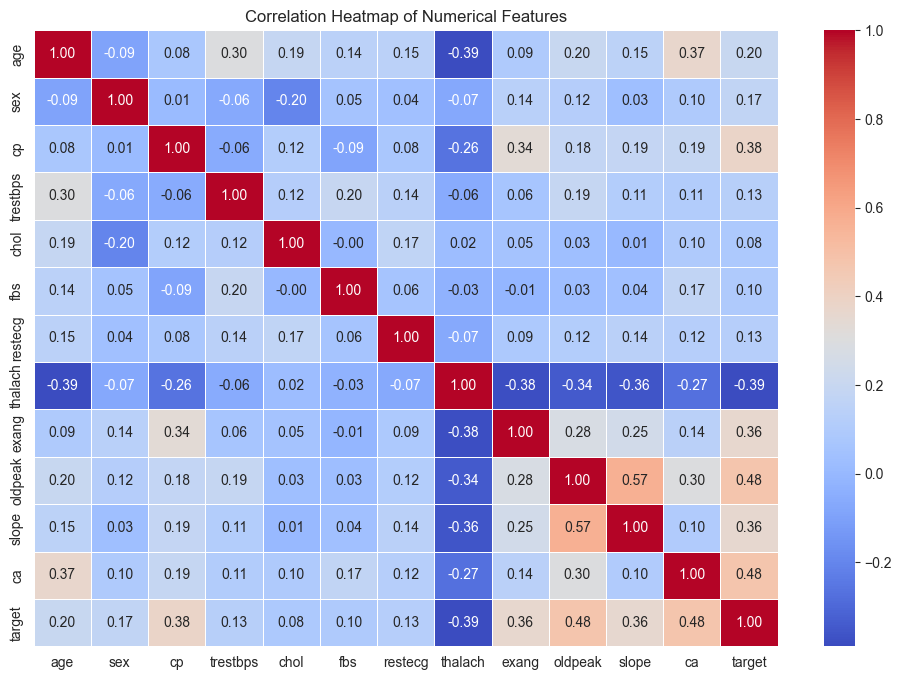

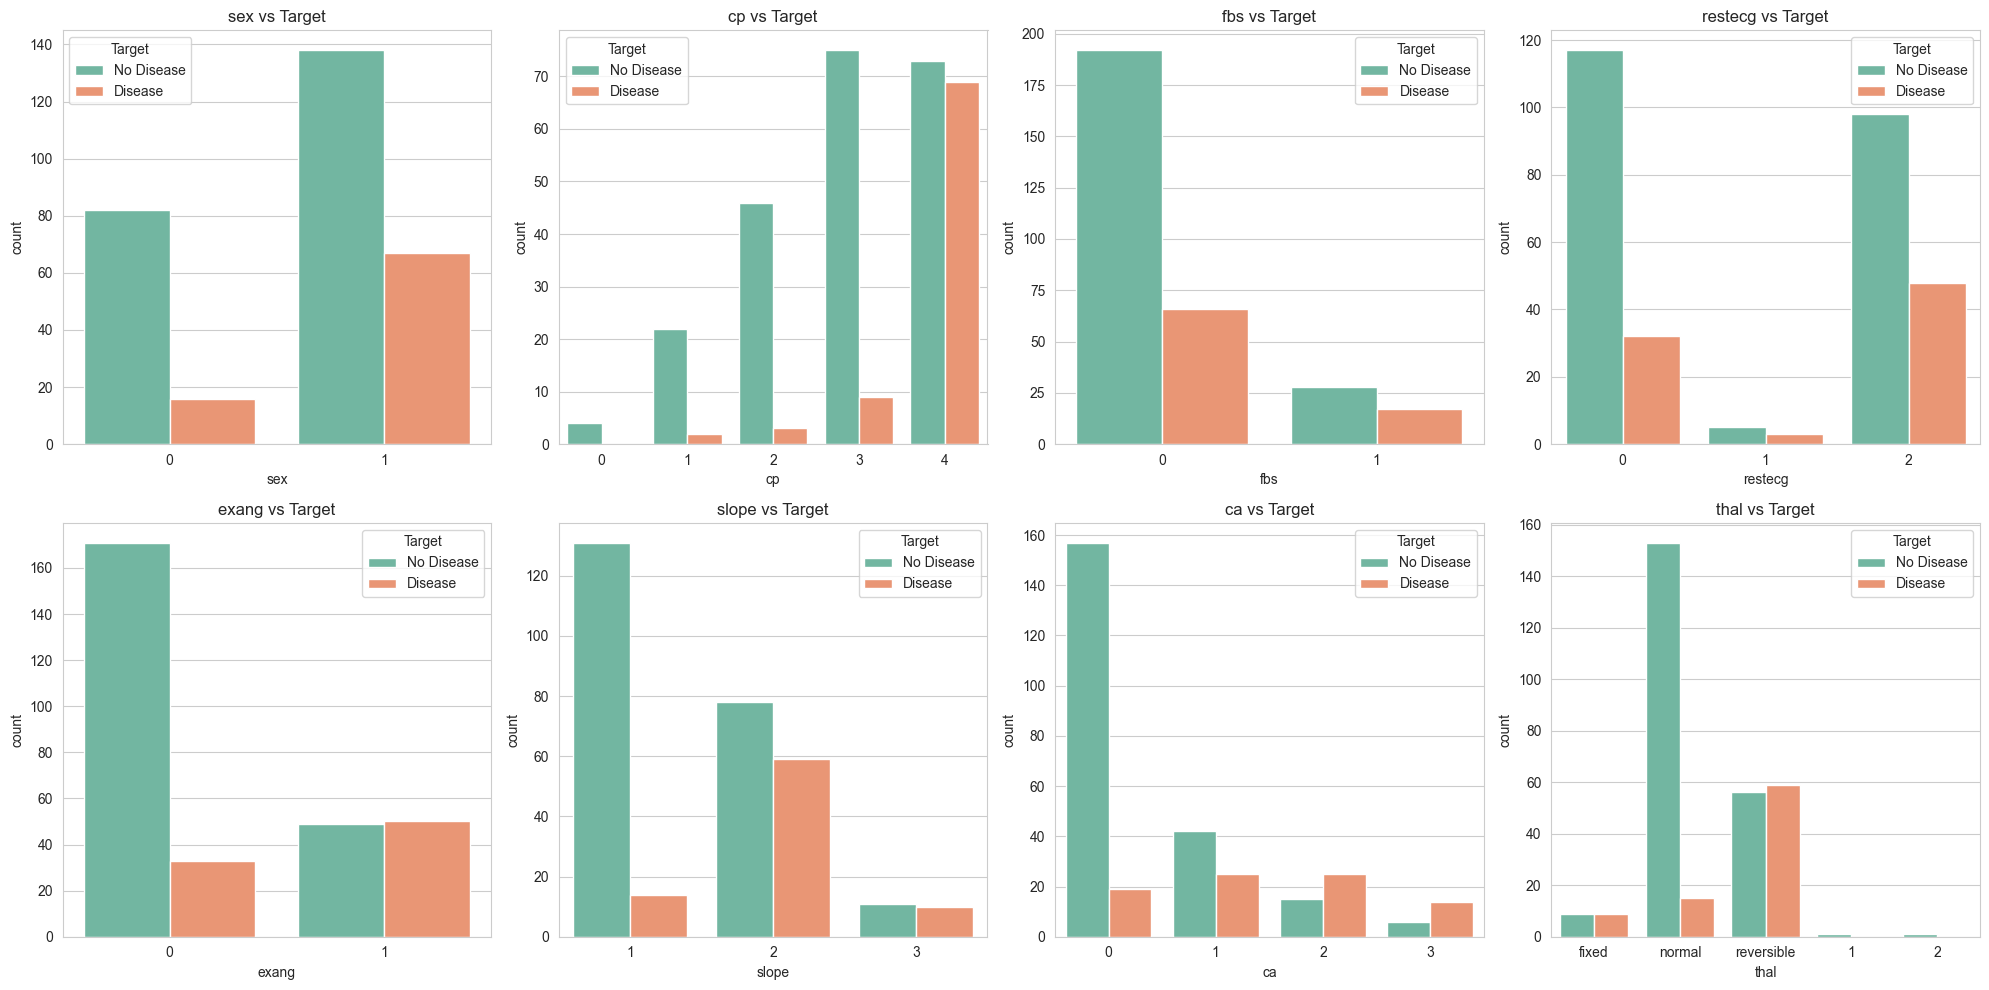

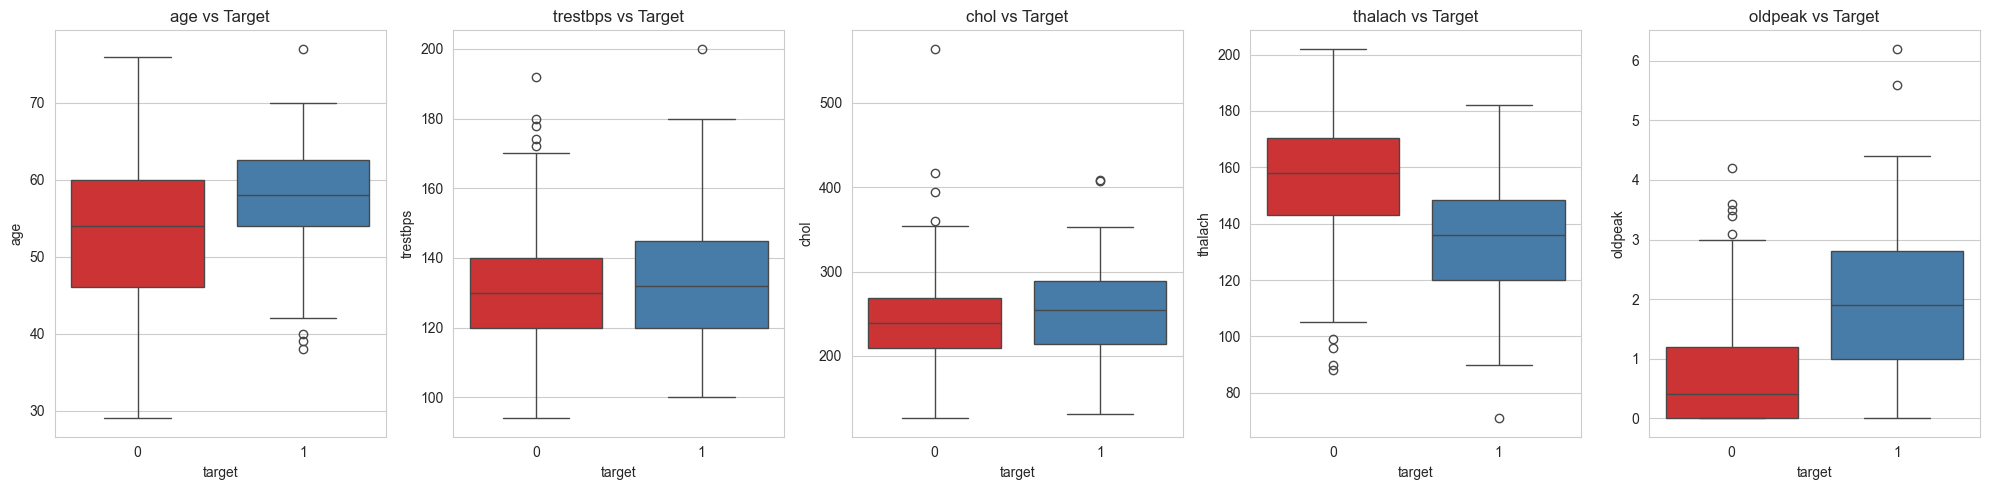

In [6]:
# EDA

# Set visualization style 
sns.set_style("whitegrid")

# 2. Target Variable Distribution

plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='viridis', hue='target', legend=False)
plt.title('Distribution of Heart Disease (0 = No, 1 = Yes)')
plt.xlabel('Target (0 = No Disease, 1 = Disease)')
plt.ylabel('Count')
plt.show()

# 3. Correlation Heatmap (Numerical Features)
plt.figure(figsize=(12, 8))
numerical_df = df.select_dtypes(include=[np.number])
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


# 4. Categorical Features vs Target

categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(x=col, hue='target', data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs Target')
    axes[i].legend(title='Target', labels=['No Disease', 'Disease'])

plt.tight_layout()
plt.show()

# 5. Numerical Features vs Target (Boxplots)
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, col in enumerate(numerical_features):
    sns.boxplot(x='target', y=col, data=df, hue='target', legend=False, ax=axes[i], palette='Set1')
    axes[i].set_title(f'{col} vs Target')

plt.tight_layout()
plt.show()

In [8]:
# preprocessing and feature engineering

#  Separate Features (X) and Target (y)
X = df.drop('target', axis=1)
y = df['target']

# Identify Numerical and Categorical columns
# Numerical features that need scaling
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Categorical features that need One-Hot Encoding
# Note: 'thal' is a string, the rest are integers but represent categories
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

#  Create a Preprocessing Pipeline using ColumnTransformer
# This applies scaling to numeric features and one-hot encoding to categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features) # drop='first' avoids multicollinearity
    ])

# Split the data into Training (80%) and Testing (20%) sets
#  stratify=y to ensure both sets have the same proportion of target classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Apply the Preprocessing Pipeline
# Fit on the training data ONLY to prevent data leakage, then transform both train and test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 7. Display the new shapes of our data
print("--- Data Shapes After Preprocessing ---")
print(f"Original X_train shape: {X_train.shape}")
print(f"Processed X_train shape: {X_train_processed.shape}")
print(f"Processed X_test shape: {X_test_processed.shape}")

# Inspect the new feature names
# Get feature names from the OneHotEncoder
cat_encoder = preprocessor.named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)

# Create a DataFrame to view the processed training data
X_train_df = pd.DataFrame(X_train_processed, columns=all_feature_names)
print("\n--- First 5 rows of Processed Training Data ---")
display(X_train_df.head())

--- Data Shapes After Preprocessing ---
Original X_train shape: (242, 13)
Processed X_train shape: (242, 23)
Processed X_test shape: (61, 23)

--- First 5 rows of Processed Training Data ---


,age,trestbps,chol,thalach,oldpeak,sex_1,cp_1,cp_2,cp_3,cp_4,...,exang_1,slope_2,slope_3,ca_1,ca_2,ca_3,thal_2,thal_fixed,thal_normal,thal_reversible
0,2.151169,-0.683495,0.374034,-1.174881,-0.742399,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.300731,1.146089,0.914263,1.259961,0.103062,1.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.702319,0.116948,-0.277966,-0.149684,1.286708,1.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,2.485519,-0.397623,1.026035,0.576496,-0.911491,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,-2.195380,-0.340448,0.616206,0.320197,-0.911491,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [10]:
# model training and hyperparameter tuning
# Define the models and their hyperparameter grids
models_and_params = {
    "SVM": {
        "model": SVC(probability=True, random_state=42),
        "params": {
            'C': [0.1, 1, 10],
            'kernel': ['linear', 'rbf'],
            'gamma': ['scale', 'auto']
        }
    },
    "XGBoost": {
        "model": XGBClassifier(eval_metric='logloss', random_state=42),
        "params": {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1]
        }
    },
    "Naive Bayes": {
        "model": GaussianNB(),
        "params": {
            'var_smoothing': [1e-9, 1e-8, 1e-7]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5]
        }
    }
}

#  Dictionary to store the best models
best_models = {}

#  Loop through each model, perform GridSearchCV, and store the best estimator
print("--- Starting Model Training and Hyperparameter Tuning ---\n")

for model_name, config in models_and_params.items():
    print(f"Training {model_name}...")
    start_time = time.time()
    
    # Setup GridSearchCV
    # We use scoring='recall' to prioritize minimizing False Negatives
    grid_search = GridSearchCV(
        estimator=config["model"],
        param_grid=config["params"],
        cv=5, 
        scoring='recall', 
        n_jobs=-1 
    )
    
    # Fit the model
    grid_search.fit(X_train_processed, y_train)
    
    # Store the best model
    best_models[model_name] = grid_search.best_estimator_
    
    # Print results
    end_time = time.time()
    print(f"  Best Parameters: {grid_search.best_params_}")
    print(f"  Best Recall Score (CV): {grid_search.best_score_:.4f}")
    print(f"  Time taken: {end_time - start_time:.2f} seconds\n")

print("--- Training Complete! ---")
print("The best models have been saved in the 'best_models' dictionary.")

--- Starting Model Training and Hyperparameter Tuning ---

Training SVM...
  Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
  Best Recall Score (CV): 0.7407
  Time taken: 10.17 seconds

Training XGBoost...
  Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
  Best Recall Score (CV): 0.5440
  Time taken: 6.91 seconds

Training Naive Bayes...
  Best Parameters: {'var_smoothing': 1e-09}
  Best Recall Score (CV): 0.8923
  Time taken: 0.11 seconds

Training Random Forest...
  Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
  Best Recall Score (CV): 0.5418
  Time taken: 9.72 seconds

--- Training Complete! ---
The best models have been saved in the 'best_models' dictionary.


--- Evaluating Models on the Test Set ---


--- Model Performance Comparison (Sorted by Recall) ---


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Naive Bayes,0.754098,0.535714,0.882353,0.666667,0.874332
1,SVM,0.852459,0.833333,0.588235,0.689655,0.955882
2,Random Forest,0.819672,0.875000,0.411765,0.560000,0.947861
3,XGBoost,0.770492,0.800000,0.235294,0.363636,0.909091


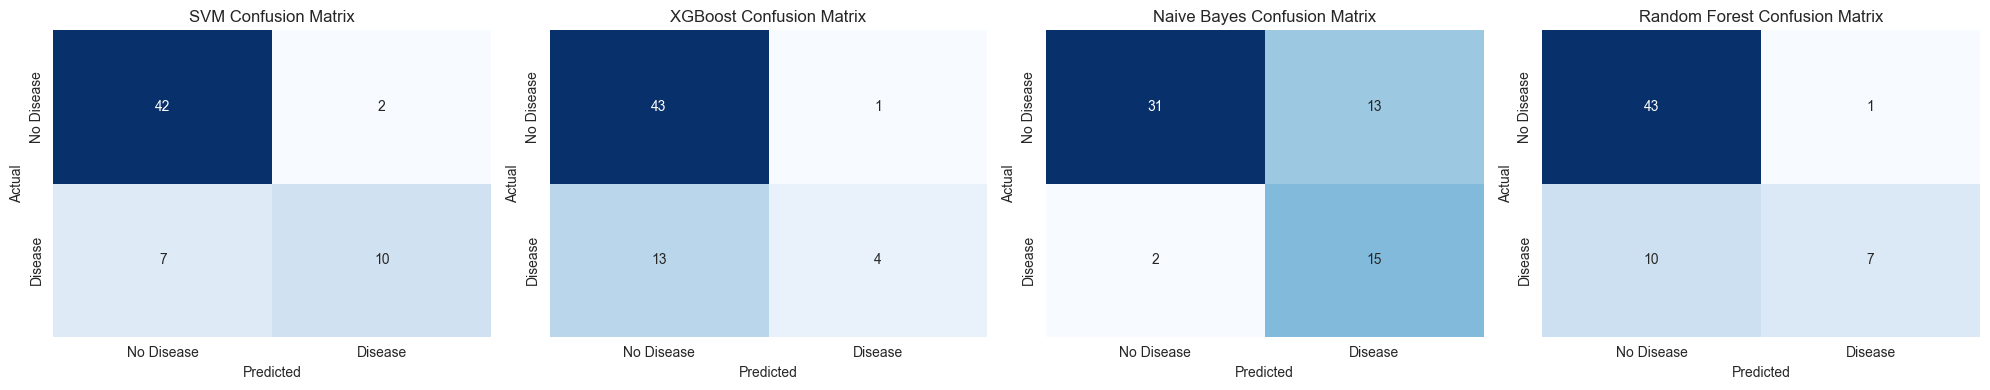

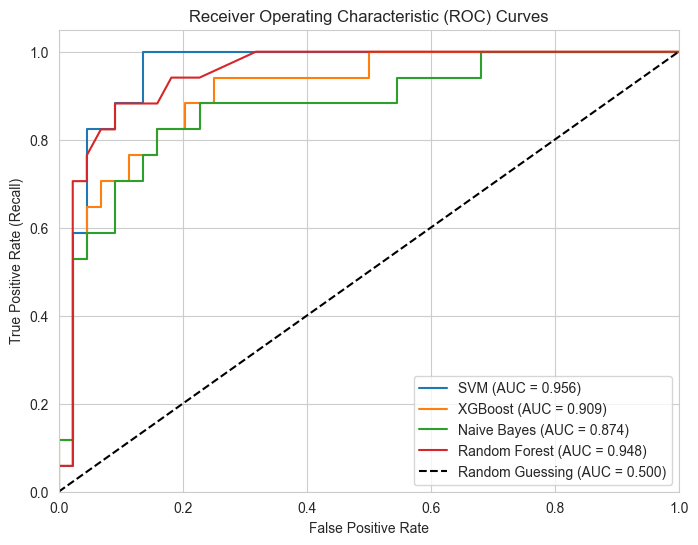

In [12]:
# model evaluation and comparison
# Dictionary to store evaluation metrics
metrics_dict = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': [],
    'ROC-AUC': []
}

#Dictionary to store predictions and probabilities for plotting
predictions = {}
probabilities = {}

# Loop through the best models to evaluate
print("--- Evaluating Models on the Test Set ---\n")

for model_name, model in best_models.items():
    # Predict class labels
    y_pred = model.predict(X_test_processed)
    
    # Predict probabilities (for ROC-AUC)
    y_prob = model.predict_proba(X_test_processed)[:, 1]
    
    # Store predictions for later use
    predictions[model_name] = y_pred
    probabilities[model_name] = y_prob
    
    # Calculate metrics
    metrics_dict['Model'].append(model_name)
    metrics_dict['Accuracy'].append(accuracy_score(y_test, y_pred))
    metrics_dict['Precision'].append(precision_score(y_test, y_pred))
    metrics_dict['Recall'].append(recall_score(y_test, y_pred))
    metrics_dict['F1-Score'].append(f1_score(y_test, y_pred))
    metrics_dict['ROC-AUC'].append(roc_auc_score(y_test, y_prob))

# 4. Create a DataFrame to display the comparison
metrics_df = pd.DataFrame(metrics_dict)
metrics_df = metrics_df.sort_values(by='Recall', ascending=False).reset_index(drop=True)

print("\n--- Model Performance Comparison (Sorted by Recall) ---")
display(metrics_df.style.background_gradient(cmap='Blues', subset=['Recall', 'F1-Score', 'ROC-AUC']))

# 5. Plot Confusion Matrices
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for i, (model_name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'{model_name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
    axes[i].set_xticklabels(['No Disease', 'Disease'])
    axes[i].set_yticklabels(['No Disease', 'Disease'])

plt.tight_layout()
plt.show()

# 6. Plot ROC Curves
plt.figure(figsize=(8, 6))
for model_name, y_prob in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.3f})')

# Plot the diagonal baseline (random guessing)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc="lower right")
plt.show()

In [13]:
# save the model and preprocessor
import joblib

# Save the best SVM model
joblib.dump(best_models['SVM'], 'svm_heart_model.pkl')

# Save the preprocessor (crucial for scaling and encoding new inputs)
joblib.dump(preprocessor, 'heart_preprocessor.pkl')

print("Model and Preprocessor saved successfully!")

Model and Preprocessor saved successfully!


In [17]:
# SHAP
import shap
import numpy as np
import matplotlib.pyplot as plt

# 1. Initialize the SHAP Explainer
print("Initializing SHAP explainer...")
explainer = shap.KernelExplainer(
    best_models['SVM'].predict_proba, 
    shap.sample(X_train_processed, 50)
)

# 2. Calculate SHAP values for a subset of the test set
# Using a smaller sample (e.g., 50) makes this much faster
X_test_subset = X_test_processed[:50]
shap_values = explainer.shap_values(X_test_subset)

# 3. Inspect the shape to understand the format
print(f"Shape of shap_values: {np.shape(shap_values)}")
print(f"Type of shap_values: {type(shap_values)}")

Initializing SHAP explainer...


  0%|          | 0/50 [00:00<?, ?it/s]

Shape of shap_values: (50, 23, 2)
Type of shap_values: <class 'numpy.ndarray'>


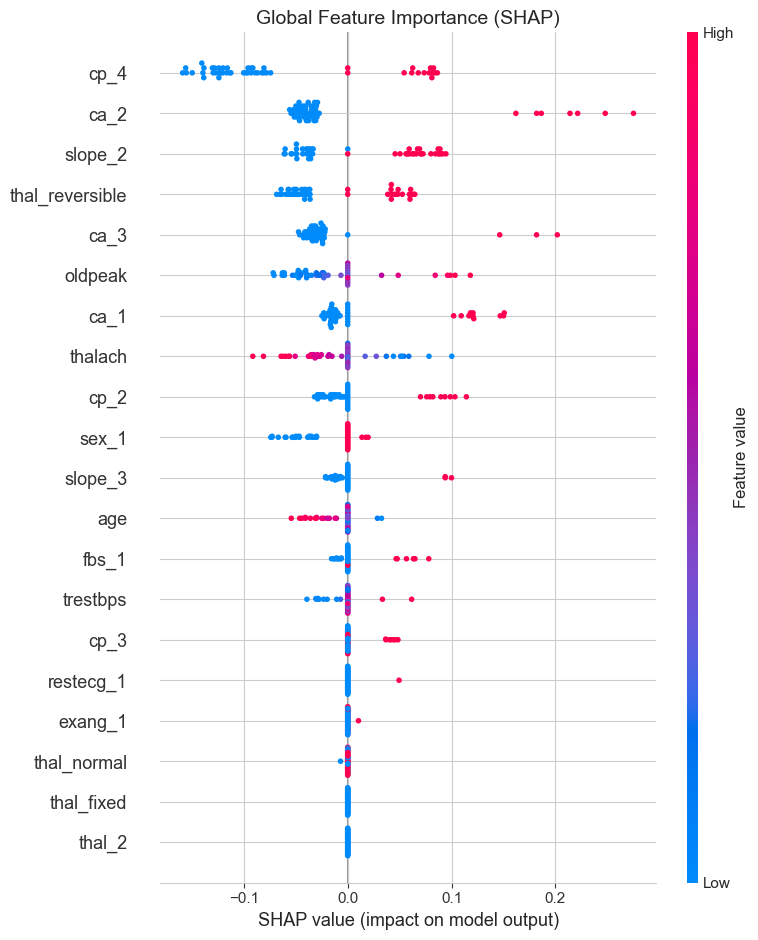

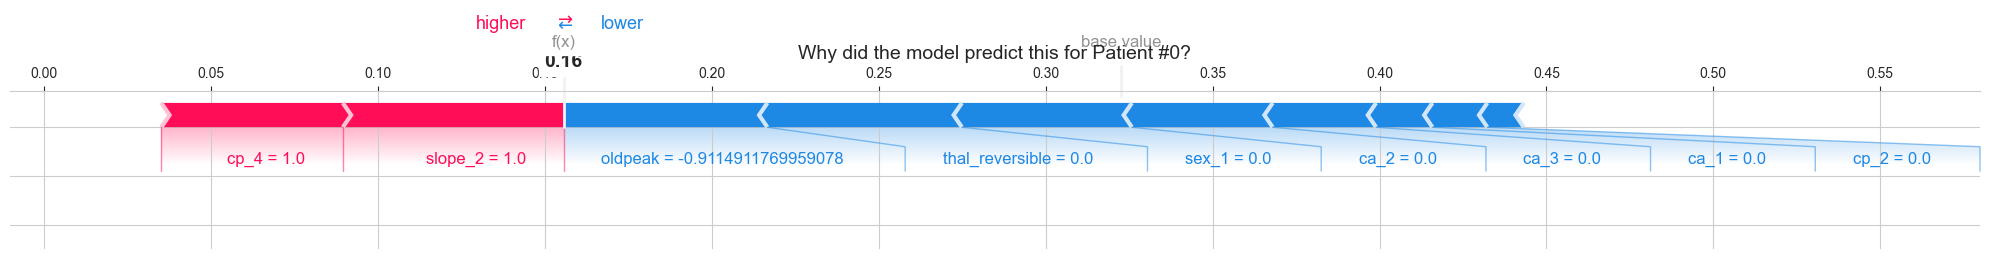

In [19]:

# 1. Extract the 2D matrix for the "Disease" class (Class 1)
shap_values_disease = shap_values[:, :, 1]
base_value = explainer.expected_value[1]

# 2. Global Interpretability: Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_disease, 
    X_test_subset, 
    feature_names=all_feature_names, 
    show=False
)
plt.title("Global Feature Importance (SHAP)", fontsize=14)
plt.tight_layout()
plt.show()

# 3. Local Interpretability: Force Plot for Patient #0
shap.initjs()
shap.force_plot(
    base_value, 
    shap_values_disease[0], 
    X_test_subset[0], 
    feature_names=all_feature_names,
    matplotlib=True, 
    show=False
)
plt.title("Why did the model predict this for Patient #0?", fontsize=14)
plt.tight_layout()
plt.show()

In [21]:
%pip install lime

  Using cached lime-0.2.0.1-py3-none-any.whl
  Using cached scikit_image-0.26.0-cp314-cp314-win_amd64.whl.metadata (15 kB)
  Using cached networkx-3.7-py3-none-any.whl.metadata (6.7 kB)
  Using cached imageio-2.37.4-py3-none-any.whl.metadata (9.6 kB)
  Using cached tifffile-2026.9.20-py3-none-any.whl.metadata (34 kB)
  Using cached lazy_loader-0.6-py3-none-any.whl.metadata (6.0 kB)
Using cached scikit_image-0.26.0-cp314-cp314-win_amd64.whl (12.0 MB)
Using cached imageio-2.37.4-py3-none-any.whl (318 kB)
Using cached lazy_loader-0.6-py3-none-any.whl (8.8 kB)
Using cached networkx-3.7-py3-none-any.whl (2.1 MB)
Using cached tifffile-2026.9.20-py3-none-any.whl (275 kB)

   ---------------------------------------- 0/6 [tifffile]
   ---------------------------------------- 0/6 [tifffile]
   ---------------------------------------- 0/6 [tifffile]
   ---------------------------------------- 0/6 [tifffile]
   ---------------------------------------- 0/6 [tifffile]
   ----------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Generating LIME explanation for Patient #0...


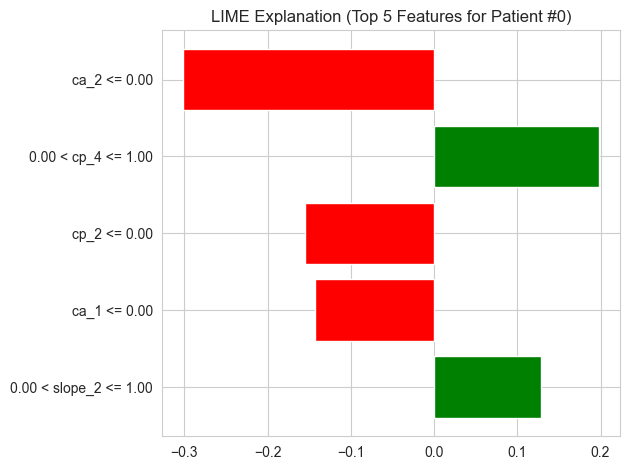


SVM Predicted Probability of Disease for Patient #0: 15.55%


In [22]:
# LIME
import lime
import lime.lime_tabular
import numpy as np
import matplotlib.pyplot as plt

# 1. Initialize the LIME Explainer
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_processed),
    feature_names=all_feature_names,
    class_names=['No Disease', 'Disease'],
    mode='classification'
)

# 2. Explain Patient #0 (same patient as the SHAP force plot)
print("Generating LIME explanation for Patient #0...")
exp = explainer_lime.explain_instance(
    data_row=X_test_processed[0], 
    predict_fn=best_models['SVM'].predict_proba,
    num_features=5 # Show top 5 most influential features
)

# 3. Visualize
fig = exp.as_pyplot_figure()
plt.title("LIME Explanation (Top 5 Features for Patient #0)")
plt.tight_layout()
plt.show()

# 4. Print the actual prediction probability for context
prob = best_models['SVM'].predict_proba(X_test_processed[0].reshape(1, -1))[0][1]
print(f"\nSVM Predicted Probability of Disease for Patient #0: {prob*100:.2f}%")